# 00. Data quality (raw 5m OHLC)

Walk-through of the raw 5m CSVs that drive the rest of the pipeline. We
load each asset with `src.data.data_ib.load_5m_ohlc` (the same loader
every experiment uses), report coverage and bar counts, sanity-check the
realised-volatility distribution, then resample one focal asset to the
four pipeline frequencies (5m / 15m / 1h / 1d) so the reader can see how
the bar count drops as the resolution coarsens.

**Inputs**: `data/{SPY,USDJPY,CL,GLD}_5m.csv` (and `data_2022/`).

**To regenerate the raw CSVs**: `python run.py pipeline --download` (requires
Interactive Brokers Gateway / TWS).

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

PROJECT = Path.cwd()
_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file is not None:
    PROJECT = Path(_nb_file).resolve().parent.parent
elif PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT))

OUT = PROJECT / "outputs"
OUT_2022 = PROJECT / "outputs_2022"
DATA = PROJECT / "data"
DATA_2022 = PROJECT / "data_2022"

pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 50)

## Step 1 -- load all four 5m series via `load_5m_ohlc`

In [2]:
from src.data.data_ib import load_5m_ohlc

frames = {}
for asset in ['SPY', 'USDJPY', 'CL', 'GLD']:
    p = DATA / f"{asset}_5m.csv"
    if p.exists():
        frames[asset] = load_5m_ohlc(p)
    else:
        display(Markdown(f"`{p.name}` not found -- run `python run.py pipeline --download` first."))

## Step 2 -- coverage and bar-count table

In [3]:
rows = []
for asset, df in frames.items():
    rows.append({
        "asset": asset,
        "n_bars": len(df),
        "first": df.index.min(),
        "last": df.index.max(),
        "n_trading_days": df.index.normalize().nunique(),
    })
pd.DataFrame(rows).set_index("asset")

,n_bars,first,last,n_trading_days
asset,,,,
SPY,23688,2025-11-03 04:00:00-05:00,2026-05-01 15:55:00-04:00,124
USDJPY,36393,2025-11-02 17:15:00-05:00,2026-05-01 15:55:00-04:00,156
CL,34896,2025-11-02 18:00:00-05:00,2026-05-01 16:55:00-04:00,155
GLD,23688,2025-11-03 04:00:00-05:00,2026-05-01 15:55:00-04:00,124


## Step 3 -- 5m realised-volatility distribution

Quick sanity check before regime fitting: each asset's `|H - L|` (per-bar range) on a log scale should be roughly unimodal. A second mode would suggest a structural break or a data-quality issue (e.g., stale-quote chunks).

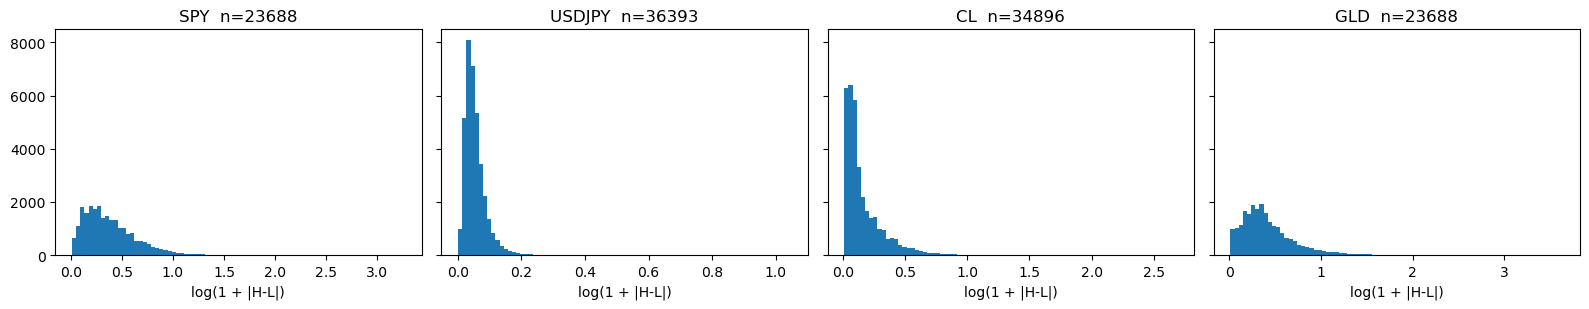

In [4]:
fig, axes = plt.subplots(1, len(frames), figsize=(4*len(frames), 3.2), sharey=True)
if len(frames) == 1:
    axes = [axes]
for ax, (asset, df) in zip(axes, frames.items()):
    rv = (df["High"] - df["Low"]).abs()
    ax.hist(np.log1p(rv.replace(0, np.nan).dropna()), bins=80)
    ax.set_title(f"{asset}  n={len(df)}")
    ax.set_xlabel("log(1 + |H-L|)")
plt.tight_layout()
plt.show()

## Step 4 -- resample `CL` to the four pipeline frequencies

Show how the bar count drops as the resolution coarsens. The downstream regime-fitting and cross-frequency ARI are computed on the labels produced from these four resampled OHLC frames.

In [5]:
from src.core.features import resample_ohlc

if 'CL' in frames:
    df_focal = frames['CL']
    rows = [{"freq": "5m_raw", "n_bars": len(df_focal)}]
    for freq in ("5m", "15m", "1h", "1d"):
        ohlc = resample_ohlc(df_focal, freq)
        rows.append({"freq": freq, "n_bars": len(ohlc)})
    display(pd.DataFrame(rows).set_index("freq"))

,n_bars
freq,
5m_raw,34896
5m,34896
15m,11759
1h,3037
1d,155


## Why these four assets?

- **SPY** -- the SPDR S&P 500 ETF (tradable, executable bid/ask, real volume); preferred over the index because the index is non-tradable and stale-quote-prone.
- **USD/JPY** -- the canonical safe-haven leg of geopolitical risk transmission; tri-session microstructure (Tokyo / London / NY) makes it the most informative cross-frequency stress on regime classifiers.
- **CL** (WTI continuous front-month) -- 2026 only; contract-roll structure is the only commodity-specific microstructure feature in the paper; included as a diagnostic that roll weeks do not drive the cross-frequency dissonance result (see `01_main_pipeline` Table A.13).
- **GLD** (SPDR Gold Trust) -- precious-metal proxy added so the 2022 OOS episode has a non-equity / non-FX leg. CL=F was unobtainable for 2022 (IB CONTFUT history limit + expired contracts purged from security master); GLD's gold-as-safe-haven response to the 2022 invasion makes it a clean substitute.

For full motivation see Section 2 of `paper/main.tex`.